In [1]:
%%bash

pip install rasterio
pip install pillow
pip install cmweather
wget -nc -q https://nimbus.niu.edu/courses/EAE483/BREF_090508_1300.png
wget -nc -q https://nimbus.niu.edu/courses/EAE483/000000274089.tif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 1.7 MB/s eta 0:00:00


In [2]:
from PIL import Image

def read_and_subset_radar_png(filename):
    img = Image.open(filename)
    img = np.array(img)
    img = img[600:1000, 1700:2100]
    img = img * 5

    return img

# Chapter 9.3 - Image Filters

In previous chapters, we explored how images can be modified / manipulated using basic "numpy math" operations. In addition, we saw how segmentation can specifically identify regions / clusters within images. While more complicated, this approach also uses basic conditional tests to initially identify foreground and background pixels. In this chapter, we will introduce slightly more complex math that will allow us to transform images in a way that accentuates or helps identify [image features](https://en.wikipedia.org/wiki/Feature_(computer_vision)) that could be used for machine learning applications. These transformations include [blurring](https://en.wikipedia.org/wiki/Box_blur), sharpening, [edge detection](https://en.wikipedia.org/wiki/Edge_detection), and others.

Example of edge detection:

<img src=https://upload.wikimedia.org/wikipedia/commons/5/50/Vd-Orig.png></img>
<img src=https://upload.wikimedia.org/wikipedia/commons/0/0b/Vd-Rige2.png></img>


### Chapter 9.3.1 - 1D Convolution

[Convolution](https://en.wikipedia.org/wiki/Kernel_(image_processing)#Convolution) within digital images is one of the foundational transformation methods of modern machine learning. This process is similar to [mathematical convolution](https://en.wikipedia.org/wiki/Convolution)--namely, multiplying two functions and finding the integral. This type of transformation typically uses a special type of function called a kernel that is specifically designed to identify and amplify / attenuate a signal within the original function.

We can use a kernel and convolution to calculate a simple climatological statistic--a 7-day running mean. This calculation considers:

1. An "anchor" date (e.g., the "valid" date)
2. 3 dates before the anchor date
3. 3 dates after the anchor date

This totals 7 different days of data to consider. If you were to take the mean, you might do something like:







In [3]:
import numpy as np

data_days = [0, 1, 2, 0, 0, 5, 5]

ave_7day = np.mean(data_days)

print(f"{ave_7day:.2f}")

1.86


Alternatively, you might instead create a `kernel` that provides a weight for each day based on its position:

*Think about this: why is the weight ~0.14 for each date?*

In [4]:
window = 7

kernel = np.ones(shape=window) / 7

print("Kernel for each date in list =", kernel)
print(f"Sum of kernel = {np.sum(kernel):.2f}")

Kernel for each date in list = [0.14285714 0.14285714 0.14285714 0.14285714 0.14285714 0.14285714
 0.14285714]
Sum of kernel = 1.00


and multiply this by the actual data and find the sum. This is a bit backwards from how you might usually do it (sum -> quotient), but it works the same. Since the kernel weights add up to 1, each value in the original list provides an equal "contribution" to the result:

In [5]:
conv = np.sum(kernel * data_days)

print(f"{conv:.2f}")

1.86


If you wanted to weight the days closer to the valid date more in the calculation, you could modify the weights. However, this will cause the result to diverge from the mean. Notice how despite the kernel values also adding up to 1, the days farther away have lower weights than dates closer to the valid date. The average is lower due to how the precipitation data sets up around the valid date--namely the two `5` values are two and three days from the valid date.

In [6]:
custom_kernel = np.array([0.05, 0.10, 0.20, 0.30, 0.20, 0.10, 0.05])

conv_custom = np.sum(custom_kernel * data_days)

print("Rainfall totals for each day in window", data_days)
print("Kernel for each date in list =", custom_kernel)
print(f"Sum of kernel = {np.sum(custom_kernel):.2f}")
print(f"Center weighting average = {conv_custom:.2f}")

Rainfall totals for each day in window [0, 1, 2, 0, 0, 5, 5]
Kernel for each date in list = [0.05 0.1  0.2  0.3  0.2  0.1  0.05]
Sum of kernel = 1.00
Center weighting average = 1.25


We can extend this calculation to longer time periods and create a `moving average` time series.

Set the "rainfall data":

Text(0.5, 0, 'Date')

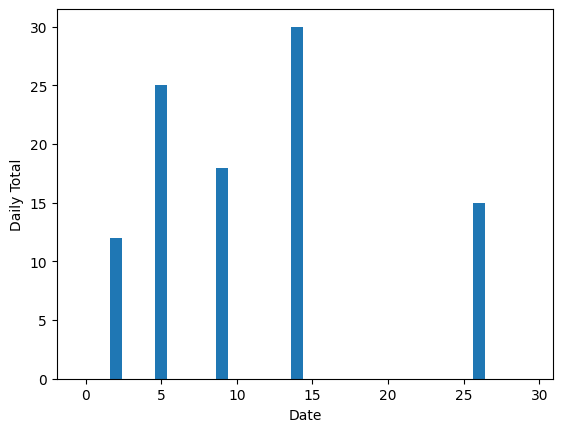

In [7]:
import numpy as np
import matplotlib.pyplot as plt

rain = np.array([
    0, 0, 12, 0, 0, 25, 0, 0, 0, 18,
    0, 0, 0, 0, 30, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 15, 0, 0, 0
], dtype=float)

days = np.array(range(len(rain)))

plt.bar(range(len(rain)), rain)
plt.ylabel("Daily Total")
plt.xlabel("Date")

Next, we define the kernel for a regular 7-day moving average (e.g., equal weights):

In [8]:
window_size = 7

kernel = np.ones(shape=window_size) / window_size

print(f"Number of days: {len(rain)}")
print(f"Kernel width: {window_size} days")
print(f"Kernel weights: {kernel}")

Number of days: 30
Kernel width: 7 days
Kernel weights: [0.14285714 0.14285714 0.14285714 0.14285714 0.14285714 0.14285714
 0.14285714]


We can use the built-in `convolve` function from `numpy` to calculate the moving window averages for all possible 7-day windows in the time period:

In [9]:
ma = np.convolve(rain, kernel, mode="same")

print(ma)

[1.71428571 1.71428571 5.28571429 5.28571429 5.28571429 5.28571429
 6.14285714 6.14285714 6.14285714 2.57142857 2.57142857 6.85714286
 6.85714286 4.28571429 4.28571429 4.28571429 4.28571429 4.28571429
 0.         0.         0.         0.         0.         2.14285714
 2.14285714 2.14285714 2.14285714 2.14285714 2.14285714 2.14285714]


Spot check for the 5th valid date (index 4), with a 7-day window running from index 4-3 (1) to 4+3 (7).

In [10]:
print(rain[1:8])

print(f"average = {np.mean(rain[1:8])})")

[ 0. 12.  0.  0. 25.  0.  0.]
average = 5.285714285714286)


Use a widget and the built-in convolution function from `numpy`:

In [11]:
import ipywidgets as widgets
from ipywidgets import interact

def plot_window(center_day):

    center_idx = int(center_day) - 1
    half = window // 2
    start = center_idx - half
    end = center_idx + half

    in_window = (days >= start + 1) & (days <= end + 1)

    vals = []
    for idx in range(start, end + 1):
        if 0 <= idx < len(rain):
            vals.append(rain[idx])
        else:
            vals.append(0.0)
    vals = np.array(vals, dtype=float)
    actual_avg = vals.mean()

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)

    ax = axes[0]
    ax.bar(days, rain, width=0.8)
    ax.set_title("Daily Rainfall with 7-Day Moving-Average Window")
    ax.set_xlabel("Day")
    ax.set_ylabel("Rainfall (mm/day)")
    ax.set_xlim(0.5, len(days) + 0.5)

    ymax = max(35, rain.max() * 1.15)
    ax.set_ylim(0, ymax)

    left_edge = start + 0.5
    right_edge = end + 1.5
    ax.axvspan(left_edge, right_edge, alpha=0.2)
    ax.axvline(center_day, linestyle="--")

    ax.bar(days[in_window], rain[in_window], width=0.8)

    ax2 = axes[1]
    ax2.plot(days, ma, marker="o")
    ax2.scatter([center_day], [ma[center_idx]], s=80)
    ax2.set_title("7-Day Moving Average")
    ax2.set_xlabel("Day")
    ax2.set_ylabel("Average rainfall (mm/day)")
    ax2.set_xlim(0.5, len(days) + 0.5)
    ax2.axvspan(left_edge, right_edge, alpha=0.15)
    ax2.axvline(center_day, linestyle="--")

    window_days = list(range(start + 1, end + 2))
    fig.suptitle(
        "Selected center day: {cd} | Window days: {wd} | "
        "7-day average (including zero-rain days): {avg:.2f} mm/day".format(
            cd=center_day, wd=window_days, avg=actual_avg
        ),
        fontsize=13
    )

    plt.show()

interact(
    plot_window,
    center_day=widgets.IntSlider(
        value=4,
        min=4,
        max=len(days)-3,
        step=1,
        description="Center day"
    )
);


interactive(children=(IntSlider(value=4, description='Center day', max=27, min=4), Output()), _dom_classes=('w…

### Chapter 9.3.2 - 2D convolutions

We can calculate convolutions in two dimensions using a 2D kernel applied in a moving window to a 2D digital image. `scipy` provides a function called `convolve2d` that allows us to easily run this calculation.

We will do it by hand for the first example.

Some common 2D kernels include:

1. `Identity kernel` - if you multiply pixels in the 3x3 neighborhood by each value associated with that pixel position, you get mostly zeroes, except for the center pixel which is multiplied by 1.

```
[[0, 0, 0],
 [0, 1, 0],
 [0, 0, 0]]
```


Convolutions can clip the image by requiring that there are valid pixels within each window. On the edges of the images, you may have a row or column that is beyond the edge of the original image. As a result, those pixels are thrown out, and the new image size is reduced as the edges do not result in a valid convolution.

This approach is how the `valid` argument for `mode` works in `convolve2d`. Below is equivalent to output using `mode='valid'`:

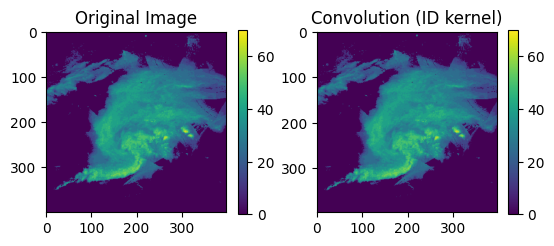

In [12]:
from PIL import Image

id_kern = np.array([[0, 0, 0],
                    [0, 1, 0],
                    [0, 0, 0]])


img = read_and_subset_radar_png("BREF_090508_1300.png")

ax = plt.subplot(1, 2, 1)
ax.set_title("Original Image")
mmp = ax.imshow(img)
plt.colorbar(mmp, ax=ax, shrink=0.5)

img_height, img_width = img.shape
kernel_height, kernel_width = id_kern.shape

new_height = img_height - kernel_height + 1
new_width = img_width - kernel_width + 1

out = np.zeros((new_height, new_width), dtype=float)

for i in range(new_height):
    for j in range(new_width):

        kernel_h_extent = i + kernel_height
        kernel_w_extent = j + kernel_width

        region = img[i:kernel_h_extent, j:kernel_w_extent]
        out[i, j] = np.sum(region * id_kern)

ax = plt.subplot(1, 2, 2)
ax.set_title("Convolution (ID kernel)")
mmp = ax.imshow(out)
plt.colorbar(mmp, ax=ax, shrink=0.5)


2. `Edge detector kernel` - This [Sobel filter](https://en.wikipedia.org/wiki/Sobel_operator) estimates the image gradient in the x-direction, so it responds strongly to vertical edges.

```
[[-1, 0, 1],
 [-2, 0, 2],
 [-1, 0, 1]]
```

It will be flipped 180 degrees during the convolution step:

```
[[1, 0, -1],
 [2, 0, -2],
 [1, 0, -1]]
```


To demonstrate the influence of this kernel, consider the following image:

```
[[5, 5, 0],
 [5, 5, 0],
 [5, 5, 0]]
```

There are very high values on the left and low values in the right columns.

After the kernel is flipped for convolution, the larger values on the left are multiplied by positive weights and the smaller values on the right are multiplied by negative weights.

As a result, the negatives are "less negative than the positive contributions", and you get a large positive value for that convolution. Note that the pixels in the central column do not contribute to the convolution.

The expansion of the convolution will look something like this:

$image =$
\begin{bmatrix}
5 & 5 & 0 \\
5 & 5 & 0 \\
5 & 5 & 0
\end{bmatrix}

$kernel =$
\begin{bmatrix}
1 & 0 & -1 \\
2 & 0 & -2 \\
1 & 0 & -1
\end{bmatrix}


$image * kernel =
(5∗1)+(5∗0)+(0∗−1)+(5∗2)+(5∗0)+(0∗−2)+(5∗1)+(5∗0)+(0∗−1)
$

$image * kernel =
= 5 + 0 + 0 + 10 + 0 + 0 + 5 + 0 + 0
$

$image * kernel = 20$

We should get the same result with `convolve2d`


In [13]:
from scipy.signal import convolve2d

edge_kern = np.array([[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]])

eg_img = np.array([[5, 5, 0],
                   [5, 5, 0],
                   [5, 5, 0]])

print("conv = ", convolve2d(eg_img, edge_kern, mode='valid'))

conv =  [[20]]


Applying it to our image:

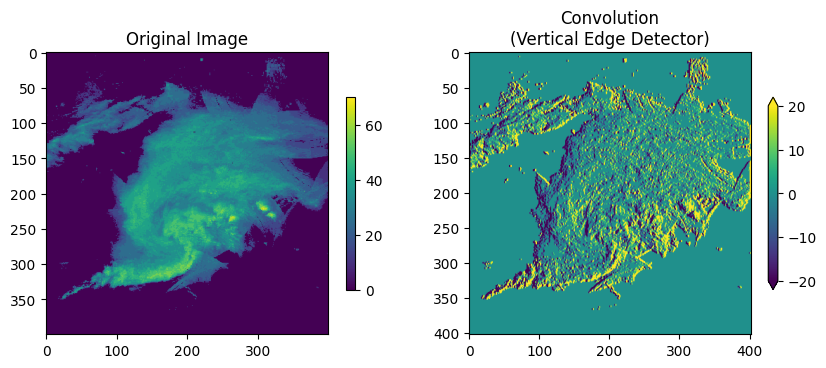

In [14]:
plt.rcParams['figure.figsize'] = 10, 5

img = read_and_subset_radar_png("BREF_090508_1300.png")

ax = plt.subplot(1, 2, 1)
ax.set_title("Original Image")
mmp = ax.imshow(img)
plt.colorbar(mmp, ax=ax, shrink=0.5)

conv = convolve2d(img, edge_kern)

ax = plt.subplot(1, 2, 2)
ax.set_title("Convolution\n(Vertical Edge Detector)")
mmp = ax.imshow(conv, vmin=-20, vmax=20)
plt.colorbar(mmp, ax=ax, shrink=0.5, extend='both')

We can apply a threshold to the original image to really pull out the edges.

*Think about this: why is one edge negative and the other edge positive? How might we detect the strongest vertical edges in all cases?*

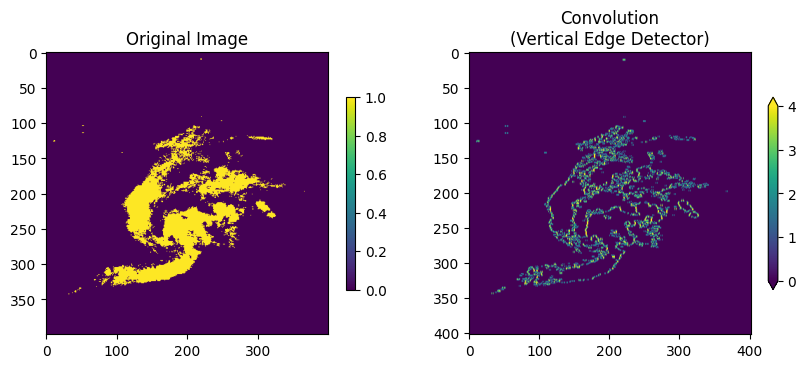

In [15]:
plt.rcParams['figure.figsize'] = 10, 5

img = read_and_subset_radar_png("BREF_090508_1300.png")
img = img >= 40

ax = plt.subplot(1, 2, 1)
ax.set_title("Original Image")
mmp = ax.imshow(img)
plt.colorbar(mmp, ax=ax, shrink=0.5)

conv = convolve2d(img, edge_kern)

ax = plt.subplot(1, 2, 2)
ax.set_title("Convolution\n(Vertical Edge Detector)")
mmp = ax.imshow(np.abs(conv))
plt.colorbar(mmp, ax=ax, shrink=0.5, extend='both')


3. `Blur kernel` - this is similar to the running mean we calculated above. This gives an equal weight to every pixel in the kernel.

```
[[1/9, 1/9, 1/9],
 [1/9, 1/9, 1/9],
 [1/9, 1/9, 1/9]]
```
Change `blur_steps` to get a more or less blurry result.

*Think about this: how do we know that each pixel is given an equal weight? why are the weights in this kernel a specific value?*

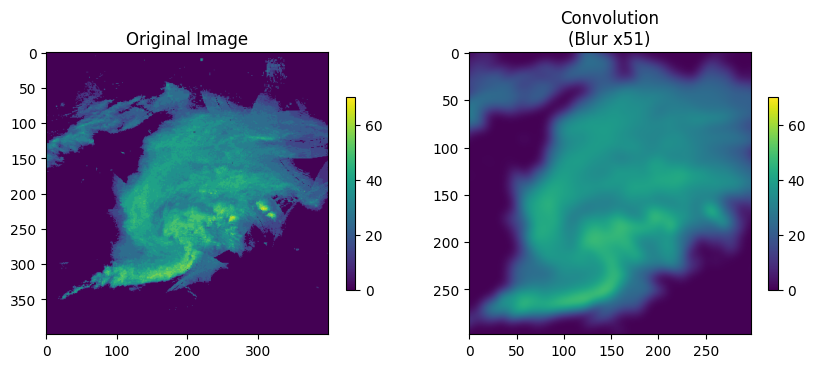

In [16]:
plt.rcParams['figure.figsize'] = 10, 5

blur_kern = np.array([[1/9, 1/9, 1/9],
                      [1/9, 1/9, 1/9],
                      [1/9, 1/9, 1/9]])

img = read_and_subset_radar_png("BREF_090508_1300.png")

ax = plt.subplot(1, 2, 1)
ax.set_title("Original Image")
mmp = ax.imshow(img, vmax=70)
plt.colorbar(mmp, ax=ax, shrink=0.5)

conv = convolve2d(img, blur_kern, mode='valid')

blur_steps = 50

for i in range(blur_steps):
    conv = convolve2d(conv, blur_kern, mode='valid')

ax = plt.subplot(1, 2, 2)
ax.set_title(f"Convolution\n(Blur x{blur_steps+1})")
mmp = ax.imshow(conv, vmin=0, vmax=70)
plt.colorbar(mmp, ax=ax, shrink=0.5)

4. `Sharpen kernel` - this kernel boosts local contrasts / edges. If the nearby pixels are all the same, this kernel simplifies to the identity kernel. If the nearby pixels are different, the differences are amplified.

```
[[0, -1, 0],
 [-1, 5, -1],
 [0, -1, 0]]
```

Change `sharp_steps` to increase the sharpness of the image.

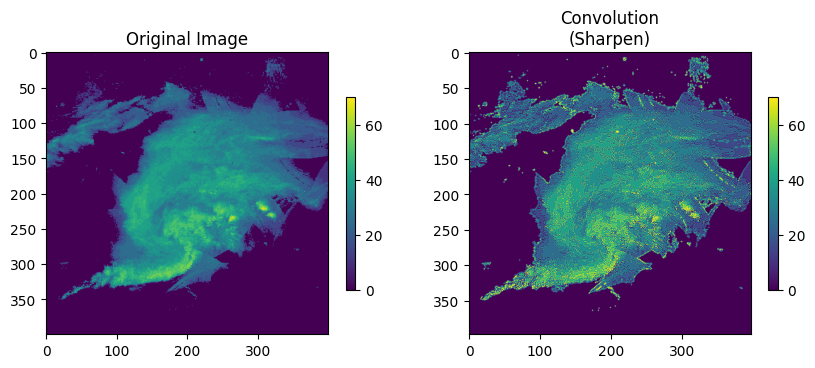

In [17]:
plt.rcParams['figure.figsize'] = 10, 5

edge_kern = np.array([[0, -1, 0],
                      [-1, 5, -1],
                      [0, -1, 0]])

img = read_and_subset_radar_png("BREF_090508_1300.png")

ax = plt.subplot(1, 2, 1)
ax.set_title("Original Image")
mmp = ax.imshow(img, vmax=70)
plt.colorbar(mmp, ax=ax, shrink=0.5)

conv = convolve2d(img, edge_kern, mode='valid')

ax = plt.subplot(1, 2, 2)
ax.set_title(f"Convolution\n(Sharpen)")
mmp = ax.imshow(np.abs(conv), vmin=0, vmax=70)
plt.colorbar(mmp, ax=ax, shrink=0.5)